# Automatic Derivatives Using PyTorch

This notebook demonstrates automatic differentiation using PyTorch's autograd system. PyTorch is widely used in deep learning and provides efficient gradient computation through computational graphs.

In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import time

## PyTorch Autograd: The Big Picture

PyTorch's **autograd** system automatically computes gradients by:

1. **Building a Computational Graph**: When you perform operations on tensors with `requires_grad=True`, PyTorch records those operations
2. **Reverse-Mode Automatic Differentiation**: Uses backpropagation to compute gradients efficiently
3. **Computing Gradients**: Call `.backward()` to compute all gradients with respect to leaf variables

### Key Concepts

- **Tensor**: Multi-dimensional array (like NumPy arrays)
- **requires_grad=True**: Marks a tensor to track operations for gradient computation
- **.backward()**: Performs backpropagation to compute gradients
- **.grad**: Stores the computed gradient
- **.zero_grad()**: Clears accumulated gradients (important in training loops)

### Why PyTorch Autograd?

- **Efficient**: Uses reverse-mode AD (backpropagation), optimal for scalar outputs
- **Dynamic**: Computational graph is built on-the-fly (eager execution)
- **GPU Support**: Can compute gradients on GPUs for massive speedups
- **Deep Learning**: Designed specifically for neural networks and optimization
- **Pythonic**: Easy to debug and understand

## Example 1: Simple Gradient Computation

Computing the gradient of f(x) = x² at different points.

In [12]:
# Example 1: f(x) = x^2
# Analytical derivative: f'(x) = 2x

print("="*70)
print("Example 1: f(x) = x^2")
print("Analytical derivative: f'(x) = 2x")
print("="*70)
print()
print("Using PyTorch Autograd:")

x_values = [1.0, 2.0, 3.0, 4.0, 5.0]
for x_val in x_values:
    # Create a tensor with requires_grad=True to enable gradient tracking
    x = torch.tensor(x_val, requires_grad=True)
    
    # Compute the function
    y = x**2
    print(f"current y: {y} current x: {x}")
    
    # Compute gradient
    y.backward()
    
    # Extract gradient value
    grad_value = x.grad.item()
    analytical = 2 * x_val
    
    print(f"  f'({x_val}) = {grad_value:.4f}  (analytical: {analytical:.4f})")

Example 1: f(x) = x^2
Analytical derivative: f'(x) = 2x

Using PyTorch Autograd:
current y: 1.0 current x: 1.0
  f'(1.0) = 2.0000  (analytical: 2.0000)
current y: 4.0 current x: 2.0
  f'(2.0) = 4.0000  (analytical: 4.0000)
current y: 9.0 current x: 3.0
  f'(3.0) = 6.0000  (analytical: 6.0000)
current y: 16.0 current x: 4.0
  f'(4.0) = 8.0000  (analytical: 8.0000)
current y: 25.0 current x: 5.0
  f'(5.0) = 10.0000  (analytical: 10.0000)


## Example 2: Computing Gradients of Trigonometric Functions

In [13]:
# Example 2: f(x) = sin(x), f'(x) = cos(x)

print()
print("="*70)
print("Example 2: f(x) = sin(x)")
print("Analytical derivative: f'(x) = cos(x)")
print("="*70)

x_test = np.pi / 4

# Create tensor with gradient tracking
x = torch.tensor(x_test, requires_grad=True)

# Compute function and gradient
y = torch.sin(x)
y.backward()

# Extract values
grad_torch = x.grad.item()
analytical = np.cos(x_test)

print()
print(f"At x = π/4 ≈ {x_test:.6f}:")
print(f"  PyTorch gradient:    {grad_torch:.12f}")
print(f"  Analytical (cos):    {analytical:.12f}")
print(f"  Difference:          {abs(grad_torch - analytical):.2e}")


Example 2: f(x) = sin(x)
Analytical derivative: f'(x) = cos(x)

At x = π/4 ≈ 0.785398:
  PyTorch gradient:    0.707106769085
  Analytical (cos):    0.707106781187
  Difference:          1.21e-08


## Example 3: Composite Functions and the Chain Rule

In [14]:
# Example 3: Composite function f(x) = sin(x^2)
# Analytical derivative: f'(x) = 2x*cos(x^2)

print()
print("="*70)
print("Example 3: f(x) = sin(x^2)")
print("Analytical derivative: f'(x) = 2x*cos(x^2)")
print("="*70)

x_test_values = [0.5, 1.0, 1.5, 2.0]

print()
print("Comparison:")

for x_val in x_test_values:
    # Create tensor with gradient tracking
    x = torch.tensor(x_val, requires_grad=True)
    
    # Compute composite function
    y = torch.sin(x**2)
    y.backward()
    
    # Analytical derivative
    analytical = 2 * x_val * np.cos(x_val**2)
    
    torch_grad = x.grad.item()
    print(f"  x = {x_val:.1f}: PyTorch = {torch_grad:10.8f}, Analytical = {analytical:10.8f}, Error = {abs(torch_grad - analytical):.2e}")


Example 3: f(x) = sin(x^2)
Analytical derivative: f'(x) = 2x*cos(x^2)

Comparison:
  x = 0.5: PyTorch = 0.96891242, Analytical = 0.96891242, Error = 9.46e-10
  x = 1.0: PyTorch = 1.08060467, Analytical = 1.08060461, Error = 6.07e-08
  x = 1.5: PyTorch = -1.88452101, Analytical = -1.88452087, Error = 1.39e-07
  x = 2.0: PyTorch = -2.61457443, Analytical = -2.61457448, Error = 5.11e-08


## Computing Gradients of Vector Functions

PyTorch can compute gradients with respect to vectors and matrices, essential for machine learning.

In [15]:
# Example 4: Function with vector input
# f(x) = ||x||^2 = x1^2 + x2^2 + x3^2 (sum of squares)
# Gradient: ∇f(x) = [2*x1, 2*x2, 2*x3]

print()
print("="*70)
print("Example 4: f(x) = ||x||^2 = x1^2 + x2^2 + x3^2")
print("Gradient: ∇f(x) = [2*x1, 2*x2, 2*x3]")
print("="*70)

# Create a vector with gradient tracking
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# Compute sum of squares (must be scalar for backward())
y = torch.sum(x**2)
y.backward()

# Extract gradient
torch_gradient = x.grad.numpy()
analytical_gradient = 2 * np.array([1.0, 2.0, 3.0])

print()
print(f"At x = {x.detach().numpy()}:")
print(f"  PyTorch gradient:        {torch_gradient}")
print(f"  Analytical gradient:     {analytical_gradient}")
print(f"  Max difference:          {np.max(np.abs(torch_gradient - analytical_gradient)):.2e}")


Example 4: f(x) = ||x||^2 = x1^2 + x2^2 + x3^2
Gradient: ∇f(x) = [2*x1, 2*x2, 2*x3]

At x = [1. 2. 3.]:
  PyTorch gradient:        [2. 4. 6.]
  Analytical gradient:     [2. 4. 6.]
  Max difference:          0.00e+00


## Higher-Order Derivatives

PyTorch can compute second derivatives and higher by enabling `create_graph=True`.

In [16]:
# Example 5: Higher-order derivatives
# f(x) = x^3
# f'(x) = 3x^2
# f''(x) = 6x
# f'''(x) = 6

print()
print("="*70)
print("Example 5: f(x) = x^3")
print("="*70)
print("  f(x) = x^3")
print("  f'(x) = 3x^2")
print("  f''(x) = 6x")
print("  f'''(x) = 6")
print("="*70)

x_test = 2.0

# First derivative
x = torch.tensor(x_test, requires_grad=True)
y = x**3
y.backward()
first_deriv = x.grad.item()

# Second derivative (need to enable create_graph for higher orders)
x = torch.tensor(x_test, requires_grad=True)
y = x**3
first_grad = torch.autograd.grad(y, x, create_graph=True)[0]
second_grad = torch.autograd.grad(first_grad, x, create_graph=True)[0]
third_grad = torch.autograd.grad(second_grad, x)[0]

print()
print(f"At x = {x_test}:")
print(f"  f'({x_test}) = {first_grad.item():.4f}  (analytical: {3*x_test**2:.4f})")
print(f"  f''({x_test}) = {second_grad.item():.4f}  (analytical: {6*x_test:.4f})")
print(f"  f'''({x_test}) = {third_grad.item():.4f}  (analytical: 6.0000)")


Example 5: f(x) = x^3
  f(x) = x^3
  f'(x) = 3x^2
  f''(x) = 6x
  f'''(x) = 6

At x = 2.0:
  f'(2.0) = 12.0000  (analytical: 12.0000)
  f''(2.0) = 12.0000  (analytical: 12.0000)
  f'''(2.0) = 6.0000  (analytical: 6.0000)


## Vectorized Gradient Computation

Computing gradients at multiple points efficiently using PyTorch.

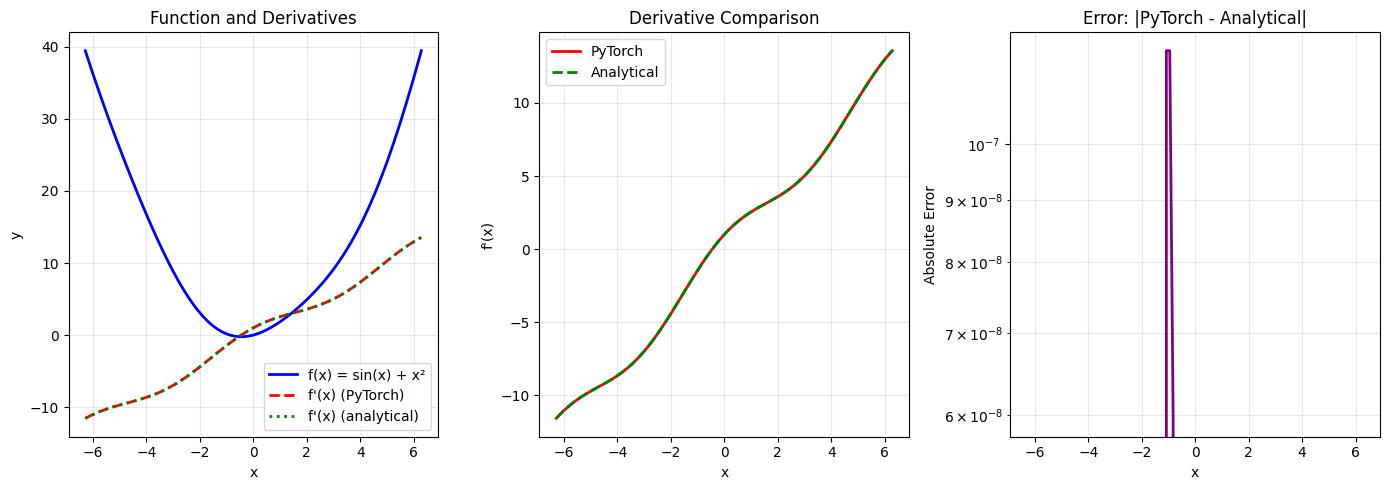


Max error: 1.19e-07
Mean error: 2.98e-09


In [17]:
# Compute gradients at multiple points
def f_test(x):
    return torch.sin(x) + x**2

# Generate x values
x = torch.linspace(-2*np.pi, 2*np.pi, 100, requires_grad=True)

# Compute function
y = f_test(x)
# For vectorized gradients, create a vector of ones and backward
y.backward(torch.ones_like(y))

# Get gradients
torch_gradients = x.grad.numpy()

# Analytical gradient: f'(x) = cos(x) + 2x
x_np = x.detach().numpy()
analytical_gradients = np.cos(x_np) + 2*x_np

# Plotting
plt.figure(figsize=(14, 5))

# Plot 1: Function and derivatives
plt.subplot(1, 3, 1)
x_detached = x.detach().numpy()
plt.plot(x_detached, np.sin(x_detached) + x_detached**2, 'b-', linewidth=2, label='f(x) = sin(x) + x²')
plt.plot(x_detached, torch_gradients, 'r--', linewidth=2, label="f'(x) (PyTorch)")
plt.plot(x_detached, analytical_gradients, 'g:', linewidth=2, label="f'(x) (analytical)")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function and Derivatives')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: PyTorch vs Analytical
plt.subplot(1, 3, 2)
plt.plot(x_detached, torch_gradients, 'r-', linewidth=2, label='PyTorch')
plt.plot(x_detached, analytical_gradients, 'g--', linewidth=2, label='Analytical')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Derivative Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Error
plt.subplot(1, 3, 3)
error = np.abs(torch_gradients - analytical_gradients)
plt.semilogy(x_detached, error, 'purple', linewidth=2)
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Error: |PyTorch - Analytical|')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print()
print(f"Max error: {np.max(error):.2e}")
print(f"Mean error: {np.mean(error):.2e}")

## Machine Learning Example: Gradient Descent Optimization


Machine Learning Example: Gradient Descent Optimization

Initial parameters: a = 1.0000, b = 0.0000

After 100 iterations (lr=0.1):
  Final parameters: a = -58709124317184.0000, b = -16261484380160.0000
  Final loss: 23524001120133333537150468096.000000
  Initial loss: 34.766998
  Loss reduction: -23524001120133333537150468096.000000


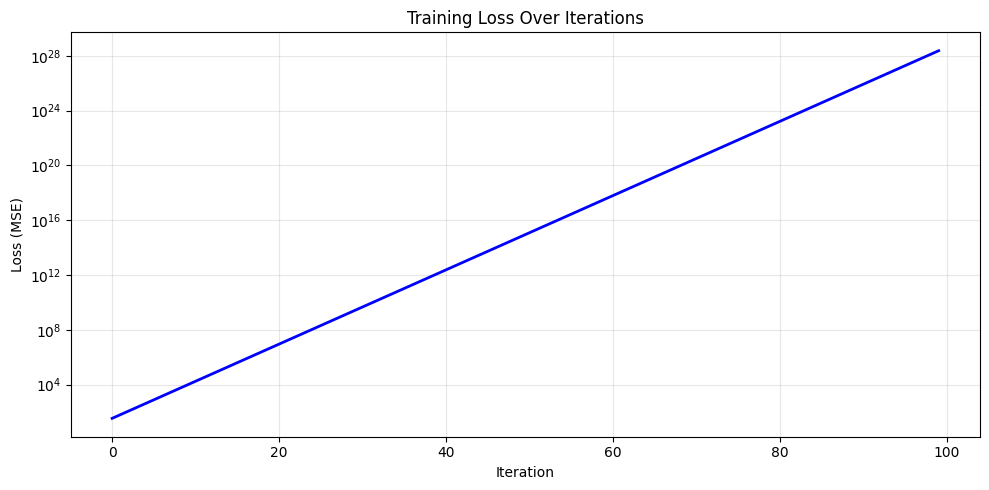

In [18]:
# Simple linear regression example using stochastic gradient descent
# Model: y_pred = a*x + b
# Loss: MSE = (1/n) * sum((y_true - y_pred)^2)

# Generate synthetic data
np.random.seed(42)
x_data = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
y_true = 2.5 * x_data + 1.0 + torch.tensor([0.1, -0.2, 0.15, -0.1, 0.05])

# Initialize parameters
a = torch.tensor([1.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

print()
print("="*70)
print("Machine Learning Example: Gradient Descent Optimization")
print("="*70)
print()
print(f"Initial parameters: a = {a.item():.4f}, b = {b.item():.4f}")

# Optimization loop
learning_rate = 0.1
num_iterations = 100

losses = []

for i in range(num_iterations):
    # Forward pass
    y_pred = a * x_data + b
    loss = torch.mean((y_true - y_pred)**2)
    losses.append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Update parameters
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
    
    # Zero gradients for next iteration
    a.grad.zero_()
    b.grad.zero_()

print()
print(f"After {num_iterations} iterations (lr={learning_rate}):")
print(f"  Final parameters: a = {a.item():.4f}, b = {b.item():.4f}")
print(f"  Final loss: {losses[-1]:.6f}")
print(f"  Initial loss: {losses[0]:.6f}")
print(f"  Loss reduction: {losses[0] - losses[-1]:.6f}")

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Iterations')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

## Comparison: PyTorch vs JAX vs SymPy

Let's compare all approaches on the same function.

In [19]:
# Test function: f(x) = e^x * sin(x)
x_val = 1.0

print()
print("="*70)
print("Comparison: SymPy vs Numerical vs PyTorch vs JAX")
print("Function: f(x) = e^x * sin(x)")
print(f"Evaluate at x = {x_val}")
print("="*70)

# 1. Symbolic (SymPy)
x_sym = sp.Symbol('x')
f_sym = sp.exp(x_sym) * sp.sin(x_sym)
f_prime_sym = sp.diff(f_sym, x_sym)
symbolic_deriv = float(f_prime_sym.subs(x_sym, x_val))

# 2. Numerical (finite differences)
h = 1e-5
numerical_deriv = (np.exp(x_val + h) * np.sin(x_val + h) - np.exp(x_val) * np.sin(x_val)) / h

# 3. PyTorch
x_torch = torch.tensor(x_val, requires_grad=True)
y_torch = torch.exp(x_torch) * torch.sin(x_torch)
y_torch.backward()
torch_deriv = x_torch.grad.item()

print()
print(f"1. Symbolic (SymPy):        {symbolic_deriv:.12f}")
print(f"2. Numerical (h=1e-5):      {numerical_deriv:.12f}")
print(f"3. PyTorch Autograd:        {torch_deriv:.12f}")

print()
print(f"Error Analysis (compared to symbolic):")
print(f"  Numerical error:        {abs(numerical_deriv - symbolic_deriv):.2e}")
print(f"  PyTorch error:          {abs(torch_deriv - symbolic_deriv):.2e}")

print()
print(f"Key Observations:")
print(f"  - Symbolic: Exact (no numerical errors)")
print(f"  - Numerical: Approximation error (depends on step size)")
print(f"  - PyTorch: Exact to machine precision (floating-point rounding only)")
print(f"  - PyTorch: GPU-accelerated, scalable to large networks")


Comparison: SymPy vs Numerical vs PyTorch vs JAX
Function: f(x) = e^x * sin(x)
Evaluate at x = 1.0

1. Symbolic (SymPy):        3.756049227095
2. Numerical (h=1e-5):      3.756063914029
3. PyTorch Autograd:        3.756049156189

Error Analysis (compared to symbolic):
  Numerical error:        1.47e-05
  PyTorch error:          7.09e-08

Key Observations:
  - Symbolic: Exact (no numerical errors)
  - Numerical: Approximation error (depends on step size)
  - PyTorch: Exact to machine precision (floating-point rounding only)
  - PyTorch: GPU-accelerated, scalable to large networks


## Performance Comparison: PyTorch vs Numerical vs SymPy

In [20]:
# Performance comparison on a more complex function
def f_complex(x):
    return torch.sin(x) * torch.exp(-x**2) + torch.cos(x**2)

# Generate test data
x_large = torch.linspace(-5, 5, 1000, requires_grad=True)

# Time PyTorch
start = time.time()
y_torch = f_complex(x_large)
y_torch.sum().backward()
torch_time = time.time() - start

# Time numerical differentiation
x_np = x_large.detach().numpy()
h = 1e-5
start = time.time()
def f_complex_np(x):
    return np.sin(x) * np.exp(-x**2) + np.cos(x**2)
numerical_grad = (f_complex_np(x_np + h) - f_complex_np(x_np)) / h
numerical_time = time.time() - start

print()
print("="*70)
print("Performance Comparison (1000 points)")
print("="*70)
print()
print(f"PyTorch Autograd:              {torch_time*1000:.3f} ms")
print(f"Numerical Differentiation:     {numerical_time*1000:.3f} ms")
print()
print(f"Speedup: {numerical_time/torch_time:.1f}x")
print()
print("Note: PyTorch shines with GPUs and larger models!")


Performance Comparison (1000 points)

PyTorch Autograd:              1.178 ms
Numerical Differentiation:     0.116 ms

Speedup: 0.1x

Note: PyTorch shines with GPUs and larger models!


## Summary: Automatic Differentiation with PyTorch

| Aspect | PyTorch | Symbolic (SymPy) | Numerical | JAX |
|--------|---------|------------------|-----------|-----|
| **Accuracy** | Exact (machine precision) | Exact | Approximate (O(h) to O(h²)) | Exact (machine precision) |
| **Computation** | Fast, especially on GPU | Can be slow for complex expressions | Fast for simple functions | Very fast, JIT compiled |
| **Type** | Reverse-mode AD (backprop) | Symbolic | Finite differences | Forward/reverse-mode AD |
| **Best for** | Deep learning, neural networks | Mathematical analysis | Simple cases | Research, ML |
| **GPU Support** | Excellent (native) | No | No | Fair (via XLA) |
| **Memory Use** | O(1) with proper handling | Can grow with complexity | Minimal | Optimal |
| **Dynamic Graphs** | Yes (eager) | Static | N/A | Yes (eager) |

### When to Use Each:

**Use PyTorch:**
- Building neural networks and deep learning models
- GPU acceleration needed
- Production machine learning systems
- Complex optimization problems
- Need dynamic graph construction

**Use SymPy:**
- Mathematical analysis and proofs
- Understanding derivative behavior
- Exact solutions required

**Use Numerical Differentiation:**
- Simple gradient checks
- Legacy code
- When analytical gradients unavailable

**Use JAX:**
- Research in scientific computing
- Functional programming approach
- Need both CPU and GPU
- JIT compilation benefits